In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("spam.csv")
df.head()
print(df['Category'].value_counts())

Category
ham     4825
spam     747
Name: count, dtype: int64


<Axes: xlabel='Category', ylabel='count'>

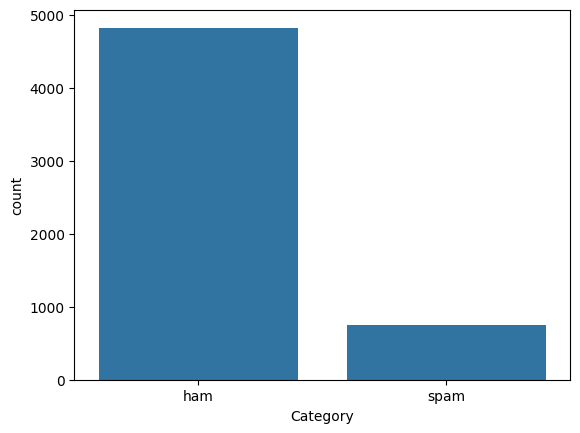

In [4]:
sns.countplot(x='Category', data=df)

In [6]:
df['Message'] = df['Message'].str.lower()
import re

df['Message'] = df['Message'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

In [7]:
#text to numbers
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['Message'])
y = df['Category']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9632286995515695
[[966   0]
 [ 41 108]]


In [12]:
#Test
message = ["Congratulations! You have won a free iPhone. Click now!"]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

print(prediction)

['spam']


In [13]:
message = ["Should we submit the file today?"]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

print(prediction)

['ham']
